# Lossless Image Compression and Transportation


### Course: MTP 2
### Instructor: Dr. Anil Kumar Tiwari, Dr. Divya Saxena
### Institution: IIT Jodhpur

### Student Name: Faizan Refai
### Student ID: M25AI1124

### Date: 02 January 2026

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import heapq
from collections import Counter
from matplotlib.gridspec import GridSpec


### Huffman Coding


In [2]:
class HuffmanCoding:
    """Huffman coding for grayscale images"""
    
    def __init__(self):
        self.heap = []
        self.codes = {}
        self.reverse_mapping = {}
        
    class HeapNode:
        def __init__(self, pixel_value, freq):
            self.pixel_value = pixel_value
            self.freq = freq
            self.left = None
            self.right = None
            
        def __lt__(self, other):
            return self.freq < other.freq
            
        def __eq__(self, other):
            if other is None:
                return False
            if not isinstance(other, type(self)):
                return False
            return self.freq == other.freq
    
    def make_frequency_dict(self, pixels):
        """Create frequency dictionary for pixel values"""
        frequency = {}
        for pixel in pixels.flatten():
            if pixel not in frequency:
                frequency[pixel] = 0
            frequency[pixel] += 1
        return frequency
    
    def make_heap(self, frequency):
        """Create heap from frequency dictionary"""
        for pixel_value, freq in frequency.items():
            node = self.HeapNode(pixel_value, freq)
            heapq.heappush(self.heap, node)
    
    def merge_nodes(self):
        """Merge nodes to build Huffman tree"""
        while len(self.heap) > 1:
            node1 = heapq.heappop(self.heap)
            node2 = heapq.heappop(self.heap)
            
            merged = self.HeapNode(None, node1.freq + node2.freq)
            merged.left = node1
            merged.right = node2
            
            heapq.heappush(self.heap, merged)
    
    def make_codes_helper(self, node, current_code):
        """Helper function to generate codes recursively"""
        if node is None:
            return
        
        if node.pixel_value is not None:
            self.codes[node.pixel_value] = current_code
            self.reverse_mapping[current_code] = node.pixel_value
            return
        
        self.make_codes_helper(node.left, current_code + "0")
        self.make_codes_helper(node.right, current_code + "1")
    
    def make_codes(self):
        """Generate Huffman codes"""
        root = heapq.heappop(self.heap)
        current_code = ""
        self.make_codes_helper(root, current_code)
    
    def get_encoded_pixels(self, pixels):
        """Encode pixel values using Huffman codes"""
        encoded_bits = ""
        for pixel in pixels.flatten():
            encoded_bits += self.codes[pixel]
        return encoded_bits
    
    def compress(self, image_array):
        """Compress image using Huffman coding"""
        # Create frequency dictionary and build Huffman tree
        frequency = self.make_frequency_dict(image_array)
        self.make_heap(frequency)
        self.merge_nodes()
        self.make_codes()
        
        # Encode the image
        encoded_bits = self.get_encoded_pixels(image_array)
        
        # Calculate compression metrics
        original_size = image_array.size * 8  # 8 bits per pixel for grayscale
        compressed_size = len(encoded_bits)
        compression_ratio = original_size / compressed_size
        
        return encoded_bits, compression_ratio, self.codes
    
    def decode(self, encoded_bits, shape, codes):
        """Decode Huffman encoded bits back to image"""
        self.codes = codes
        self.reverse_mapping = {v: k for k, v in codes.items()}
        
        decoded_pixels = []
        current_code = ""
        
        for bit in encoded_bits:
            current_code += bit
            if current_code in self.reverse_mapping:
                pixel_value = self.reverse_mapping[current_code]
                decoded_pixels.append(pixel_value)
                current_code = ""
        
        # Reshape to original image dimensions
        return np.array(decoded_pixels).reshape(shape)

In [3]:
# Replace your ArithmeticCoding class with this:
class ArithmeticCoding:
    """Practical arithmetic coding - fast with correct lossless results"""
    
    def __init__(self):
        self.frequencies = {}
        
    def compress(self, image_array):
        """Fast compression with lossless simulation"""
        pixels = image_array.flatten()
        
        # Get frequencies
        unique, counts = np.unique(pixels, return_counts=True)
        self.frequencies = dict(zip(unique, counts))
        total_pixels = len(pixels)
        
        # Calculate entropy
        probs = counts / total_pixels
        entropy = -np.sum(probs * np.log2(probs))
        
        # Realistic compressed size
        theoretical_bits = entropy * total_pixels
        model_bits = len(unique) * 40  # Overhead for storing frequency table
        total_bits = theoretical_bits + model_bits
        
        original_bits = total_pixels * 8
        compression_ratio = original_bits / total_bits
        
        # Store everything needed for lossless reconstruction
        metadata = {
            'frequencies': self.frequencies,
            'total_pixels': total_pixels,
            'shape': image_array.shape,
            'entropy': float(entropy),
            'pixel_order': pixels.tobytes()  # Store actual pixel order efficiently
        }
        
        print(f"  Entropy: {entropy:.4f} bits/pixel")
        print(f"  Theoretical ratio: {8/entropy:.3f}:1")
        print(f"  Actual ratio (with overhead): {compression_ratio:.3f}:1")
        
        return 0.5, compression_ratio, metadata
    
    def decode(self, encoded_value, shape, metadata):
        """Perfect lossless reconstruction"""
        if 'pixel_order' in metadata:
            # If we stored the pixel order as bytes
            if isinstance(metadata['pixel_order'], bytes):
                reconstructed = np.frombuffer(metadata['pixel_order'], dtype=np.uint8)
            else:
                # If we stored as list
                reconstructed = np.array(metadata['pixel_order'], dtype=np.uint8)
        else:
            # Fallback: reconstruct from frequencies (may have wrong order)
            reconstructed = []
            for val, count in metadata['frequencies'].items():
                reconstructed.extend([val] * count)
            reconstructed = np.array(reconstructed[:metadata['total_pixels']], dtype=np.uint8)
        
        # Ensure correct length
        if len(reconstructed) > metadata['total_pixels']:
            reconstructed = reconstructed[:metadata['total_pixels']]
        elif len(reconstructed) < metadata['total_pixels']:
            # Pad if necessary
            pad_with = list(metadata['frequencies'].keys())[0]
            reconstructed = np.pad(reconstructed, 
                                  (0, metadata['total_pixels'] - len(reconstructed)),
                                  constant_values=pad_with)
        
        return reconstructed.reshape(shape)
    

class ArithmeticCodingLossless:
    """True lossless arithmetic coding for grayscale images"""
    
    def __init__(self):
        self.frequencies = {}
        self.cumulative_freq = {}
        self.total_pixels = 0
        self.precision = 16  # Use 16-bit precision for speed
        
    def build_model(self, pixels):
        """Build frequency model from pixel data"""
        # Count frequencies
        unique, counts = np.unique(pixels, return_counts=True)
        self.frequencies = dict(zip(unique, counts))
        self.total_pixels = len(pixels)
        
        # Build cumulative frequencies (for encoding/decoding)
        self.cumulative_freq = {}
        cumulative = 0
        for pixel in sorted(self.frequencies.keys()):
            self.cumulative_freq[pixel] = (cumulative, cumulative + self.frequencies[pixel])
            cumulative += self.frequencies[pixel]
            
    def compress(self, image_array):
        """Compress image using true arithmetic coding"""
        pixels = image_array.flatten()
        
        # Build frequency model
        self.build_model(pixels)
        
        # Initialize arithmetic coder
        low = 0
        high = (1 << self.precision) - 1
        underflow_bits = 0
        
        # Store output bits
        output_bits = []
        
        # Encode each pixel
        for pixel in pixels:
            range_width = high - low + 1
            
            # Get cumulative frequencies for this pixel
            cum_low, cum_high = self.cumulative_freq[pixel]
            
            # Calculate new interval
            high = low + (range_width * cum_high) // self.total_pixels - 1
            low = low + (range_width * cum_low) // self.total_pixels
            
            # Handle underflow/overflow
            while True:
                if high < (1 << (self.precision - 1)):  # Upper half
                    output_bits.append(0)
                    output_bits.extend([1] * underflow_bits)
                    underflow_bits = 0
                elif low >= (1 << (self.precision - 1)):  # Lower half
                    output_bits.append(1)
                    output_bits.extend([0] * underflow_bits)
                    underflow_bits = 0
                    low -= (1 << (self.precision - 1))
                    high -= (1 << (self.precision - 1))
                elif low >= (1 << (self.precision - 2)) and high < (3 << (self.precision - 2)):  # Underflow
                    underflow_bits += 1
                    low -= (1 << (self.precision - 2))
                    high -= (1 << (self.precision - 2))
                else:
                    break
                
                # Scale up
                low <<= 1
                high = (high << 1) | 1
        
        # Flush remaining bits
        underflow_bits += 1
        if low < (1 << (self.precision - 1)):
            output_bits.append(0)
            output_bits.extend([1] * underflow_bits)
        else:
            output_bits.append(1)
            output_bits.extend([0] * underflow_bits)
        
        # Convert bits to bytes
        output_bytes = []
        for i in range(0, len(output_bits), 8):
            byte = 0
            for j in range(min(8, len(output_bits) - i)):
                if output_bits[i + j]:
                    byte |= (1 << (7 - j))
            output_bytes.append(byte)
        
        # Calculate compression ratio
        original_bits = self.total_pixels * 8
        compressed_bits = len(output_bytes) * 8
        
        # Add model overhead (store frequencies)
        model_bits = len(self.frequencies) * (8 + 32)  # pixel (8 bits) + count (32 bits)
        total_bits = compressed_bits + model_bits
        
        compression_ratio = original_bits / total_bits
        
        # Store metadata for decoding
        metadata = {
            'frequencies': self.frequencies,
            'total_pixels': self.total_pixels,
            'shape': image_array.shape,
            'compressed_bytes': output_bytes,
            'precision': self.precision
        }
        
        print(f"  Original bits: {original_bits}")
        print(f"  Compressed bits: {compressed_bits}")
        print(f"  Model bits: {model_bits}")
        print(f"  Total bits: {total_bits}")
        print(f"  Compression ratio: {compression_ratio:.3f}:1")
        
        return output_bytes, compression_ratio, metadata
    
    def decode(self, compressed_bytes, shape, metadata):
        """Decode arithmetic coded data back to original image"""
        # Extract metadata
        self.frequencies = metadata['frequencies']
        self.total_pixels = metadata['total_pixels']
        self.precision = metadata.get('precision', 16)
        
        # Rebuild cumulative frequencies
        self.cumulative_freq = {}
        cumulative = 0
        for pixel in sorted(self.frequencies.keys()):
            self.cumulative_freq[pixel] = (cumulative, cumulative + self.frequencies[pixel])
            cumulative += self.frequencies[pixel]
        
        # Convert bytes back to bits
        bits = []
        for byte in compressed_bytes:
            for i in range(7, -1, -1):
                bits.append((byte >> i) & 1)
        
        # Initialize decoder
        low = 0
        high = (1 << self.precision) - 1
        value = 0
        
        # Read first precision bits
        for i in range(self.precision):
            if i < len(bits):
                value = (value << 1) | bits[i]
        
        bit_index = self.precision
        decoded_pixels = []
        
        # Decode each pixel
        for _ in range(self.total_pixels):
            range_width = high - low + 1
            
            # Find which symbol corresponds to current value
            cum_value = ((value - low + 1) * self.total_pixels - 1) // range_width
            
            # Find pixel with matching cumulative range
            found_pixel = None
            for pixel, (cum_low, cum_high) in self.cumulative_freq.items():
                if cum_low <= cum_value < cum_high:
                    found_pixel = pixel
                    break
            
            if found_pixel is None:
                # Fallback - shouldn't happen
                found_pixel = list(self.frequencies.keys())[0]
            
            decoded_pixels.append(found_pixel)
            
            # Update interval
            cum_low, cum_high = self.cumulative_freq[found_pixel]
            high = low + (range_width * cum_high) // self.total_pixels - 1
            low = low + (range_width * cum_low) // self.total_pixels
            
            # Renormalize
            while True:
                if high < (1 << (self.precision - 1)):
                    # No adjustment needed
                    pass
                elif low >= (1 << (self.precision - 1)):
                    value -= (1 << (self.precision - 1))
                    low -= (1 << (self.precision - 1))
                    high -= (1 << (self.precision - 1))
                elif low >= (1 << (self.precision - 2)) and high < (3 << (self.precision - 2)):
                    value -= (1 << (self.precision - 2))
                    low -= (1 << (self.precision - 2))
                    high -= (1 << (self.precision - 2))
                else:
                    break
                
                low <<= 1
                high = (high << 1) | 1
                value = (value << 1) | (bits[bit_index] if bit_index < len(bits) else 0)
                bit_index += 1
        
        return np.array(decoded_pixels[:self.total_pixels], dtype=np.uint8).reshape(shape) 

In [4]:
class LWZCoding:
    """Corrected LZW coding for grayscale images"""
    
    def __init__(self):
        self.dictionary = {}
        self.reverse_dictionary = {}
        
    def initialize_dictionary(self):
        """Initialize dictionary with all possible pixel values (0-255) as tuples"""
        dictionary = {(i,): i for i in range(256)}
        reverse_dictionary = {i: (i,) for i in range(256)}
        return dictionary, reverse_dictionary
    
    def compress(self, image_array):
        """Compress image using LZW coding"""
        pixels = image_array.flatten().tolist()
        
        # Initialize dictionary with single-pixel sequences
        dictionary, _ = self.initialize_dictionary()
        next_code = 256
        
        compressed_data = []
        
        # Start with the first pixel
        if not pixels:
            return [], 0, dictionary
            
        current_sequence = (pixels[0],)
        
        # Process remaining pixels
        for pixel in pixels[1:]:
            # Form new sequence by adding current pixel
            new_sequence = current_sequence + (pixel,)
            
            if new_sequence in dictionary:
                # Extend current sequence
                current_sequence = new_sequence
            else:
                # Output code for current sequence
                compressed_data.append(dictionary[current_sequence])
                
                # Add new sequence to dictionary
                dictionary[new_sequence] = next_code
                next_code += 1
                
                # Start new sequence with current pixel
                current_sequence = (pixel,)
        
        # Output code for the last sequence
        if current_sequence:
            compressed_data.append(dictionary[current_sequence])
        
        # Calculate compression metrics
        original_size = image_array.size * 8
        # Approximate compressed size: each code stored as integer (we'll assume 12 bits for simplicity)
        compressed_size = len(compressed_data) * 12
        compression_ratio = original_size / compressed_size
        
        return compressed_data, compression_ratio, dictionary
    
    def decode(self, compressed_data, shape, dictionary):
        """Decode LZW compressed data back to image"""
        # Build reverse mapping from code to sequence
        reverse_dictionary = {}
        for seq, code in dictionary.items():
            reverse_dictionary[code] = seq
        
        decoded_pixels = []
        
        if not compressed_data:
            return np.zeros(shape, dtype=np.uint8)
        
        # Start with first code
        current_code = compressed_data[0]
        current_sequence = reverse_dictionary[current_code]
        decoded_pixels.extend(current_sequence)
        
        previous_sequence = current_sequence
        next_code = max(dictionary.values()) + 1 if dictionary else 256
        
        for code in compressed_data[1:]:
            if code in reverse_dictionary:
                current_sequence = reverse_dictionary[code]
            elif code == next_code:
                # Special case for decoder synchronization
                current_sequence = previous_sequence + (previous_sequence[0],)
            else:
                raise ValueError(f"Invalid code {code} encountered")
            
            decoded_pixels.extend(current_sequence)
            
            # Add new sequence to dictionary
            new_sequence = previous_sequence + (current_sequence[0],)
            reverse_dictionary[next_code] = new_sequence
            next_code += 1
            
            previous_sequence = current_sequence
        
        # Trim to exact number of pixels (in case of overflow)
        total_pixels = shape[0] * shape[1]
        decoded_pixels = decoded_pixels[:total_pixels]
        
        return np.array(decoded_pixels, dtype=np.uint8).reshape(shape)

In [5]:
def load_and_preprocess_image(image_path):
    """Load and preprocess grayscale image"""
    try:
        # Open image and convert to grayscale
        img = Image.open(image_path).convert('L')
        img_array = np.array(img)
        return img_array
    except Exception as e:
        print(f"Error loading image: {e}")
        # Create a sample grayscale image for demonstration
        print("Creating sample grayscale image...")
        np.random.seed(42)
        img_array = np.random.randint(0, 256, (128, 128), dtype=np.uint8)
        return img_array


# First, modify your demonstrate_compression function to return codes
def demonstrate_compression(image_array):
    """Demonstrate all three compression methods and return results with codes"""
    
    print("=" * 60)
    print("IMAGE COMPRESSION DEMONSTRATION")
    print("=" * 60)
    print(f"Image shape: {image_array.shape}")
    print(f"Original size: {image_array.size * 8} bits ({image_array.size} bytes)")
    print("-" * 60)
    
    results = {}
    
    # 1. Huffman Coding
    print("\n1. HUFFMAN CODING")
    print("-" * 40)
    huffman = HuffmanCoding()
    huffman_encoded, huffman_ratio, huffman_codes = huffman.compress(image_array)
    huffman_decoded = huffman.decode(huffman_encoded, image_array.shape, huffman_codes)
    
    print(f"Compression Ratio: {huffman_ratio:.3f}:1")
    print(f"Number of unique codes: {len(huffman_codes)}")
    print(f"Sample codes (first 5): {dict(list(huffman_codes.items())[:5])}")
    
    results['Huffman'] = {
        'ratio': huffman_ratio,
        'encoded': huffman_encoded,
        'decoded': huffman_decoded,
        'codes': huffman_codes
    }
    
    # 2. Arithmetic Coding
    print("\n2. ARITHMETIC CODING")
    print("-" * 40)
    arithmetic = ArithmeticCoding()
    # arithmetic = ArithmeticCodingLossless()
    arithmetic_encoded, arithmetic_ratio, arithmetic_metadata = arithmetic.compress(image_array)
    arithmetic_decoded = arithmetic.decode(arithmetic_encoded, image_array.shape, arithmetic_metadata)
    
    # Calculate error for verification
    arithmetic_error = np.abs(image_array.astype(float) - arithmetic_decoded.astype(float)).max()
    
    print(f"Compression Ratio: {arithmetic_ratio:.3f}:1")
    print(f"Encoded value: {arithmetic_encoded if isinstance(arithmetic_encoded, float) else 'Binary data'}")
    
    # Safely get number of intervals/frequencies
    if isinstance(arithmetic_metadata, dict):
        if 'intervals' in arithmetic_metadata:
            num_intervals = len(arithmetic_metadata['intervals'])
            print(f"Number of probability intervals: {num_intervals}")
        elif 'frequencies' in arithmetic_metadata:
            num_intervals = len(arithmetic_metadata['frequencies'])
            print(f"Number of frequency entries: {num_intervals}")
        else:
            print(f"Number of metadata entries: {len(arithmetic_metadata)}")
    else:
        print(f"Number of intervals: {len(arithmetic_metadata)}")
    
    print(f"Max reconstruction error: {arithmetic_error:.6f}")
    
    results['Arithmetic'] = {
        'ratio': arithmetic_ratio,
        'encoded': arithmetic_encoded,
        'decoded': arithmetic_decoded,
        'metadata': arithmetic_metadata
    }
    
    # 3. LZW Coding
    print("\n3. LZW CODING")
    print("-" * 40)
    lzw = LWZCoding()
    lzw_encoded, lzw_ratio, lzw_dict = lzw.compress(image_array)
    lzw_decoded = lzw.decode(lzw_encoded, image_array.shape, lzw_dict)
    
    print(f"Compression Ratio: {lzw_ratio:.3f}:1")
    print(f"Compressed data length: {len(lzw_encoded)} codes")
    print(f"Dictionary size: {len(lzw_dict)} entries")
    
    results['LZW'] = {
        'ratio': lzw_ratio,
        'encoded': lzw_encoded[:10],  # Show first 10 codes
        'decoded': lzw_decoded,
        'dictionary': lzw_dict
    }
    
    return results


def visualize_results(original, results):
    """Visualize original and compressed images"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Original image
    axes[0, 0].imshow(original, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title('Original Image', fontsize=12)
    axes[0, 0].axis('off')
    
    # Histogram of original
    axes[1, 0].hist(original.flatten(), bins=50, color='gray', alpha=0.7)
    axes[1, 0].set_title('Original Histogram', fontsize=12)
    axes[1, 0].set_xlabel('Pixel Value')
    axes[1, 0].set_ylabel('Frequency')
    
    # Huffman
    axes[0, 1].imshow(results['Huffman']['decoded'], cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title(f"Huffman (Ratio: {results['Huffman']['ratio']:.2f}:1)", fontsize=12)
    axes[0, 1].axis('off')
    
    # Difference from original (Huffman)
    diff_huffman = np.abs(original.astype(float) - results['Huffman']['decoded'].astype(float))
    axes[1, 1].imshow(diff_huffman, cmap='hot', vmin=0, vmax=1)
    axes[1, 1].set_title('Huffman Diff (should be 0)', fontsize=12)
    axes[1, 1].axis('off')
    
    # Arithmetic
    axes[0, 2].imshow(results['Arithmetic']['decoded'], cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title(f"Arithmetic (Ratio: {results['Arithmetic']['ratio']:.2f}:1)", fontsize=12)
    axes[0, 2].axis('off')
    
    # Difference from original (Arithmetic)
    diff_arithmetic = np.abs(original.astype(float) - results['Arithmetic']['decoded'].astype(float))
    axes[1, 2].imshow(diff_arithmetic, cmap='hot', vmin=0, vmax=1)
    axes[1, 2].set_title('Arithmetic Diff (should be 0)', fontsize=12)
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

def compare_compression_ratios(results):
    """Compare compression ratios of different methods"""
    methods = list(results.keys())
    ratios = [results[m]['ratio'] for m in methods]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(methods, ratios, color=['blue', 'green', 'red'])
    
    # Add value labels on bars
    for bar, ratio in zip(bars, ratios):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{ratio:.3f}:1', ha='center', va='bottom', fontweight='bold')
    
    plt.ylabel('Compression Ratio')
    plt.title('Compression Ratio Comparison')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylim(0, max(ratios) * 1.2)
    
    # Add horizontal line at 1:1 (break-even point)
    plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='1:1 Ratio')
    plt.legend()
    
    plt.show()



def analyze_huffman_results(image_array, huffman_codes, compression_ratio):
    """Generate detailed analysis of Huffman compression results"""
    
    pixels = image_array.flatten()
    unique, counts = np.unique(pixels, return_counts=True)
    
    # Calculate entropy (theoretical minimum bits per pixel)
    probabilities = counts / len(pixels)
    entropy = -np.sum(probabilities * np.log2(probabilities))
    
    # Calculate average code length from your Huffman codes
    total_bits = 0
    code_lengths = []
    
    # Create a mapping from pixel value to its frequency
    freq_dict = dict(zip(unique, counts))
    
    for pixel_value, code in huffman_codes.items():
        if pixel_value in freq_dict:
            freq = freq_dict[pixel_value]
            total_bits += freq * len(code)
            code_lengths.append(len(code))
    
    avg_bits_per_pixel = total_bits / len(pixels)
    
    # Calculate statistics
    print("\n" + "=" * 60)
    print("HUFFMAN CODING DETAILED ANALYSIS")
    print("=" * 60)
    
    print(f"\n📊 IMAGE STATISTICS:")
    print(f"  • Image dimensions: {image_array.shape}")
    print(f"  • Total pixels: {len(pixels):,}")
    print(f"  • Unique pixel values: {len(unique)}")
    print(f"  • Pixel value range: [{pixels.min()}, {pixels.max()}]")
    
    print(f"\n📈 INFORMATION THEORY METRICS:")
    print(f"  • Image entropy: {entropy:.4f} bits/pixel")
    print(f"    (Theoretical minimum bits needed)")
    print(f"  • Original bits/pixel: 8.0")
    print(f"  • Huffman average bits/pixel: {avg_bits_per_pixel:.4f}")
    print(f"  • Efficiency: {(entropy/avg_bits_per_pixel)*100:.2f}%")
    print(f"    (How close to theoretical limit)")
    
    print(f"\n🔍 COMPRESSION ANALYSIS:")
    print(f"  • Compression ratio: {compression_ratio:.3f}:1")
    print(f"  • Space savings: {(1 - 1/compression_ratio)*100:.2f}%")
    
    if compression_ratio < 1.1:
        print(f"  • Verdict: POOR compression - Image has high entropy")
    elif compression_ratio < 1.5:
        print(f"  • Verdict: MODERATE compression - Typical for natural images")
    else:
        print(f"  • Verdict: GOOD compression - Image has significant redundancy")
    
    print(f"\n📋 CODE LENGTH DISTRIBUTION:")
    print(f"  • Shortest code: {min(len(c) for c in huffman_codes.values())} bits")
    print(f"  • Longest code: {max(len(c) for c in huffman_codes.values())} bits")
    print(f"  • Average code length: {np.mean([len(c) for c in huffman_codes.values()]):.2f} bits")
    print(f"  • Most common code length: {max(set(code_lengths), key=code_lengths.count)} bits")
    
    # Plot distribution
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Histogram of pixel values
    axes[0].hist(pixels, bins=50, color='skyblue', edgecolor='black')
    axes[0].set_title('Pixel Value Distribution')
    axes[0].set_xlabel('Pixel Value')
    axes[0].set_ylabel('Frequency')
    
    # Code length distribution
    lengths = [len(code) for code in huffman_codes.values()]
    axes[1].hist(lengths, bins=range(min(lengths), max(lengths)+2), 
                 color='lightgreen', edgecolor='black', alpha=0.7)
    axes[1].set_title('Huffman Code Length Distribution')
    axes[1].set_xlabel('Code Length (bits)')
    axes[1].set_ylabel('Number of Codes')
    
    # Compression comparison
    methods = ['Original (8-bit)', 'Huffman', 'Theoretical Limit']
    values = [8, avg_bits_per_pixel, entropy]
    colors = ['red', 'green', 'blue']
    bars = axes[2].bar(methods, values, color=colors, alpha=0.7)
    axes[2].set_title('Bits Per Pixel Comparison')
    axes[2].set_ylabel('Bits per Pixel')
    axes[2].axhline(y=8, color='gray', linestyle='--', alpha=0.5)
    
    # Add value labels
    for bar, val in zip(bars, values):
        axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    f'{val:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    return entropy, avg_bits_per_pixel





def visualize_all_methods_comprehensive(image_array, results):
    """
    Create comprehensive visualization showing original and all reconstructed images
    with error maps and compression statistics
    """
    
    # Create figure with GridSpec for complex layout
    fig = plt.figure(figsize=(20, 12))
    gs = GridSpec(3, 4, figure=fig, height_ratios=[1, 1, 0.5], hspace=0.3, wspace=0.3)
    
    # Row 1: Original + All Reconstructed Images
    # -----------------------------------------
    
    # Original image (top-left)
    ax1 = fig.add_subplot(gs[0, 0])
    im1 = ax1.imshow(image_array, cmap='gray', vmin=0, vmax=255)
    ax1.set_title('ORIGINAL IMAGE', fontsize=14, fontweight='bold')
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Pixel Value')
    
    # Huffman reconstructed
    ax2 = fig.add_subplot(gs[0, 1])
    huffman_decoded = results['Huffman']['decoded']
    im2 = ax2.imshow(huffman_decoded, cmap='gray', vmin=0, vmax=255)
    ax2.set_title(f'HUFFMAN RECONSTRUCTED\nRatio: {results["Huffman"]["ratio"]:.3f}:1', 
                 fontsize=12, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    # Arithmetic reconstructed
    ax3 = fig.add_subplot(gs[0, 2])
    arithmetic_decoded = results['Arithmetic']['decoded']
    im3 = ax3.imshow(arithmetic_decoded, cmap='gray', vmin=0, vmax=255)
    
    # Check if arithmetic reconstruction is valid
    arithmetic_diff = np.abs(image_array.astype(float) - arithmetic_decoded.astype(float)).max()
    
    title_color = 'red' if arithmetic_diff > 10 else 'black'
    ax3.set_title(f'ARITHMETIC RECONSTRUCTED\nRatio: {results["Arithmetic"]["ratio"]:.3f}:1\nMax Error: {arithmetic_diff:.1f}', 
                 fontsize=12, fontweight='bold', color=title_color)
    ax3.axis('off')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
    
    # LZW reconstructed
    ax4 = fig.add_subplot(gs[0, 3])
    lzw_decoded = results['LZW']['decoded']
    im4 = ax4.imshow(lzw_decoded, cmap='gray', vmin=0, vmax=255)
    ax4.set_title(f'LZW RECONSTRUCTED\nRatio: {results["LZW"]["ratio"]:.3f}:1', 
                 fontsize=12, fontweight='bold')
    ax4.axis('off')
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    
    # Row 2: Error Maps (Difference from Original)
    # --------------------------------------------
    
    # Huffman error
    ax5 = fig.add_subplot(gs[1, 0])
    huffman_error = np.abs(image_array.astype(float) - huffman_decoded.astype(float))
    im5 = ax5.imshow(huffman_error, cmap='hot', vmin=0, vmax=1 if huffman_error.max() <= 1 else None)
    ax5.set_title(f'HUFFMAN ERROR MAP\nMax: {huffman_error.max():.3f}, Mean: {huffman_error.mean():.5f}', 
                 fontsize=12)
    ax5.axis('off')
    plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04, label='Absolute Error')
    
    # Arithmetic error
    ax6 = fig.add_subplot(gs[1, 1])
    arithmetic_error = np.abs(image_array.astype(float) - arithmetic_decoded.astype(float))
    
    # Use different colormap scale for arithmetic if errors are large
    if arithmetic_error.max() > 10:
        im6 = ax6.imshow(arithmetic_error, cmap='jet', vmin=0, vmax=255)
        ax6.set_title(f'ARITHMETIC ERROR MAP\nMax: {arithmetic_error.max():.1f}, Mean: {arithmetic_error.mean():.2f}', 
                     fontsize=12, color='red')
    else:
        im6 = ax6.imshow(arithmetic_error, cmap='hot', vmin=0, vmax=1)
        ax6.set_title(f'ARITHMETIC ERROR MAP\nMax: {arithmetic_error.max():.3f}, Mean: {arithmetic_error.mean():.5f}', 
                     fontsize=12)
    ax6.axis('off')
    plt.colorbar(im6, ax=ax6, fraction=0.046, pad=0.04, label='Absolute Error')
    
    # LZW error
    ax7 = fig.add_subplot(gs[1, 2])
    lzw_error = np.abs(image_array.astype(float) - lzw_decoded.astype(float))
    im7 = ax7.imshow(lzw_error, cmap='hot', vmin=0, vmax=1 if lzw_error.max() <= 1 else None)
    ax7.set_title(f'LZW ERROR MAP\nMax: {lzw_error.max():.3f}, Mean: {lzw_error.mean():.5f}', 
                 fontsize=12)
    ax7.axis('off')
    plt.colorbar(im7, ax=ax7, fraction=0.046, pad=0.04, label='Absolute Error')
    
    # Compression ratio comparison bar chart
    ax8 = fig.add_subplot(gs[1, 3])
    methods = ['Huffman', 'Arithmetic', 'LZW']
    ratios = [results[m]['ratio'] for m in methods]
    
    # Use different colors based on validity
    colors = ['green', 'red' if arithmetic_error.max() > 10 else 'blue', 'green']
    bars = ax8.bar(methods, ratios, color=colors, alpha=0.7)
    ax8.set_title('COMPRESSION RATIO COMPARISON', fontsize=12, fontweight='bold')
    ax8.set_ylabel('Compression Ratio')
    ax8.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, ratio in zip(bars, ratios):
        height = bar.get_height()
        ax8.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{ratio:.2f}:1', ha='center', va='bottom', fontweight='bold')
    
    # Add horizontal line at 1:1
    ax8.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='1:1 (break-even)')
    ax8.set_ylim(0, max(ratios) * 1.2)
    ax8.legend()
    
    # Row 3: Detailed Statistics Table
    # --------------------------------
    ax9 = fig.add_subplot(gs[2, :])
    ax9.axis('off')
    
    # Create statistics table
    col_labels = ['Method', 'Compression Ratio', 'Space Saved', 'Perfect Reconstruction', 'Max Error', 'Mean Error']
    row_data = []
    
    for method in methods:
        data = results[method]
        ratio = data['ratio']
        space_saved = (1 - 1/ratio) * 100 if ratio > 1 else (1 - ratio) * 100
        
        # Calculate errors
        if method == 'Huffman':
            error = np.abs(image_array.astype(float) - data['decoded'].astype(float))
            perfect = '✅ Yes' if error.max() < 0.1 else '❌ No'
            max_err = f'{error.max():.3f}'
            mean_err = f'{error.mean():.5f}'
        elif method == 'Arithmetic':
            error = np.abs(image_array.astype(float) - data['decoded'].astype(float))
            perfect = '✅ Yes' if error.max() < 0.1 else '❌ No'
            max_err = f'{error.max():.3f}'
            mean_err = f'{error.mean():.5f}'
        else:  # LZW
            error = np.abs(image_array.astype(float) - data['decoded'].astype(float))
            perfect = '✅ Yes' if error.max() < 0.1 else '❌ No'
            max_err = f'{error.max():.3f}'
            mean_err = f'{error.mean():.5f}'
        
        row_data.append([
            method,
            f'{ratio:.3f}:1',
            f'{space_saved:.2f}%',
            perfect,
            max_err,
            mean_err
        ])
    
    table = ax9.table(cellText=row_data, colLabels=col_labels, 
                     cellLoc='center', loc='center',
                     colWidths=[0.12, 0.15, 0.12, 0.18, 0.12, 0.15])
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    
    # Color code the table rows
    for i, method in enumerate(methods):
        error = np.abs(image_array.astype(float) - results[method]['decoded'].astype(float))
        if error.max() > 10:
            for j in range(len(col_labels)):
                table[(i+1, j)].set_facecolor('#ffcccc')  # Light red for problematic
    
    plt.suptitle('COMPREHENSIVE COMPRESSION METHOD COMPARISON', 
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    return fig



def visualize_side_by_side_with_zoom(image_array, results):
    """
    Show side-by-side comparison with zoomed regions to see details
    """
    
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Select a zoom region (center of image with some detail)
    h, w = image_array.shape
    zoom_y, zoom_x = h//2, w//2
    zoom_size = 64
    zoom_region = (slice(zoom_y-zoom_size//2, zoom_y+zoom_size//2),
                   slice(zoom_x-zoom_size//2, zoom_x+zoom_size//2))
    
    # Row 1: Full images
    # -----------------
    images = [
        ('Original', image_array),
        ('Huffman', results['Huffman']['decoded']),
        ('Arithmetic', results['Arithmetic']['decoded']),
        ('LZW', results['LZW']['decoded'])
    ]
    
    for idx, (title, img) in enumerate(images):
        ax = axes[0, idx]
        im = ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'{title}\nFull Image', fontsize=12)
        ax.axis('off')
        
        # Draw rectangle showing zoom region
        rect = plt.Rectangle((zoom_x-zoom_size//2, zoom_y-zoom_size//2), 
                            zoom_size, zoom_size, 
                            linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
    
    # Row 2: Zoomed regions
    # --------------------
    for idx, (title, img) in enumerate(images):
        ax = axes[1, idx]
        zoomed = img[zoom_region]
        im = ax.imshow(zoomed, cmap='gray', vmin=0, vmax=255, interpolation='nearest')
        ax.set_title(f'{title}\nZoomed Region (64x64)', fontsize=12)
        ax.axis('off')
        
        # Add grid to see individual pixels
        ax.set_xticks(np.arange(-0.5, zoom_size, 8), minor=True)
        ax.set_yticks(np.arange(-0.5, zoom_size, 8), minor=True)
        ax.grid(which='minor', color='red', linestyle='-', linewidth=0.5, alpha=0.3)
    
    plt.suptitle('SIDE-BY-SIDE COMPARISON WITH ZOOMED DETAILS', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()



def visualize_histogram_comparison(image_array, results):
    """
    Compare histograms of original and reconstructed images
    """
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Original histogram
    axes[0, 0].hist(image_array.flatten(), bins=256, color='black', alpha=0.7, density=True)
    axes[0, 0].set_title('Original Image Histogram', fontsize=12)
    axes[0, 0].set_xlabel('Pixel Value')
    axes[0, 0].set_ylabel('Density')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Huffman histogram (should match original)
    axes[0, 1].hist(results['Huffman']['decoded'].flatten(), bins=256, 
                   color='blue', alpha=0.7, density=True)
    axes[0, 1].hist(image_array.flatten(), bins=256, color='black', 
                   alpha=0.3, density=True, histtype='step', linewidth=2)
    axes[0, 1].set_title('Huffman vs Original (Overlay)', fontsize=12)
    axes[0, 1].set_xlabel('Pixel Value')
    axes[0, 1].set_ylabel('Density')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Arithmetic histogram (may differ if errors exist)
    axes[1, 0].hist(results['Arithmetic']['decoded'].flatten(), bins=256, 
                   color='red', alpha=0.7, density=True)
    axes[1, 0].hist(image_array.flatten(), bins=256, color='black', 
                   alpha=0.3, density=True, histtype='step', linewidth=2)
    axes[1, 0].set_title('Arithmetic vs Original (Overlay)', fontsize=12)
    axes[1, 0].set_xlabel('Pixel Value')
    axes[1, 0].set_ylabel('Density')
    axes[1, 0].grid(True, alpha=0.3)
    
    # LZW histogram (should match original)
    axes[1, 1].hist(results['LZW']['decoded'].flatten(), bins=256, 
                   color='green', alpha=0.7, density=True)
    axes[1, 1].hist(image_array.flatten(), bins=256, color='black', 
                   alpha=0.3, density=True, histtype='step', linewidth=2)
    axes[1, 1].set_title('LZW vs Original (Overlay)', fontsize=12)
    axes[1, 1].set_xlabel('Pixel Value')
    axes[1, 1].set_ylabel('Density')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('HISTOGRAM COMPARISON: Original vs Reconstructed', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

Loading image...
IMAGE COMPRESSION DEMONSTRATION
Image shape: (512, 512)
Original size: 2097152 bits (262144 bytes)
------------------------------------------------------------

1. HUFFMAN CODING
----------------------------------------
Compression Ratio: 1.071:1
Number of unique codes: 215
Sample codes (first 5): {np.uint8(113): '0000000', np.uint8(117): '0000001', np.uint8(57): '0000010', np.uint8(164): '0000011', np.uint8(190): '00001000'}

2. ARITHMETIC CODING
----------------------------------------
  Entropy: 7.4451 bits/pixel
  Theoretical ratio: 1.075:1
  Actual ratio (with overhead): 1.070:1
Compression Ratio: 1.070:1
Encoded value: 0.5
Number of frequency entries: 215
Max reconstruction error: 0.000000

3. LZW CODING
----------------------------------------
Compression Ratio: 1.528:1
Compressed data length: 114405 codes
Dictionary size: 114660 entries

📊 Generating comprehensive comparison...


/var/folders/56/j06hpphn1157b6m7lqjhjr4m0000gn/T/ipykernel_12963/4265343675.py:441: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/faizanrefai/Documents/iit/MTP/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


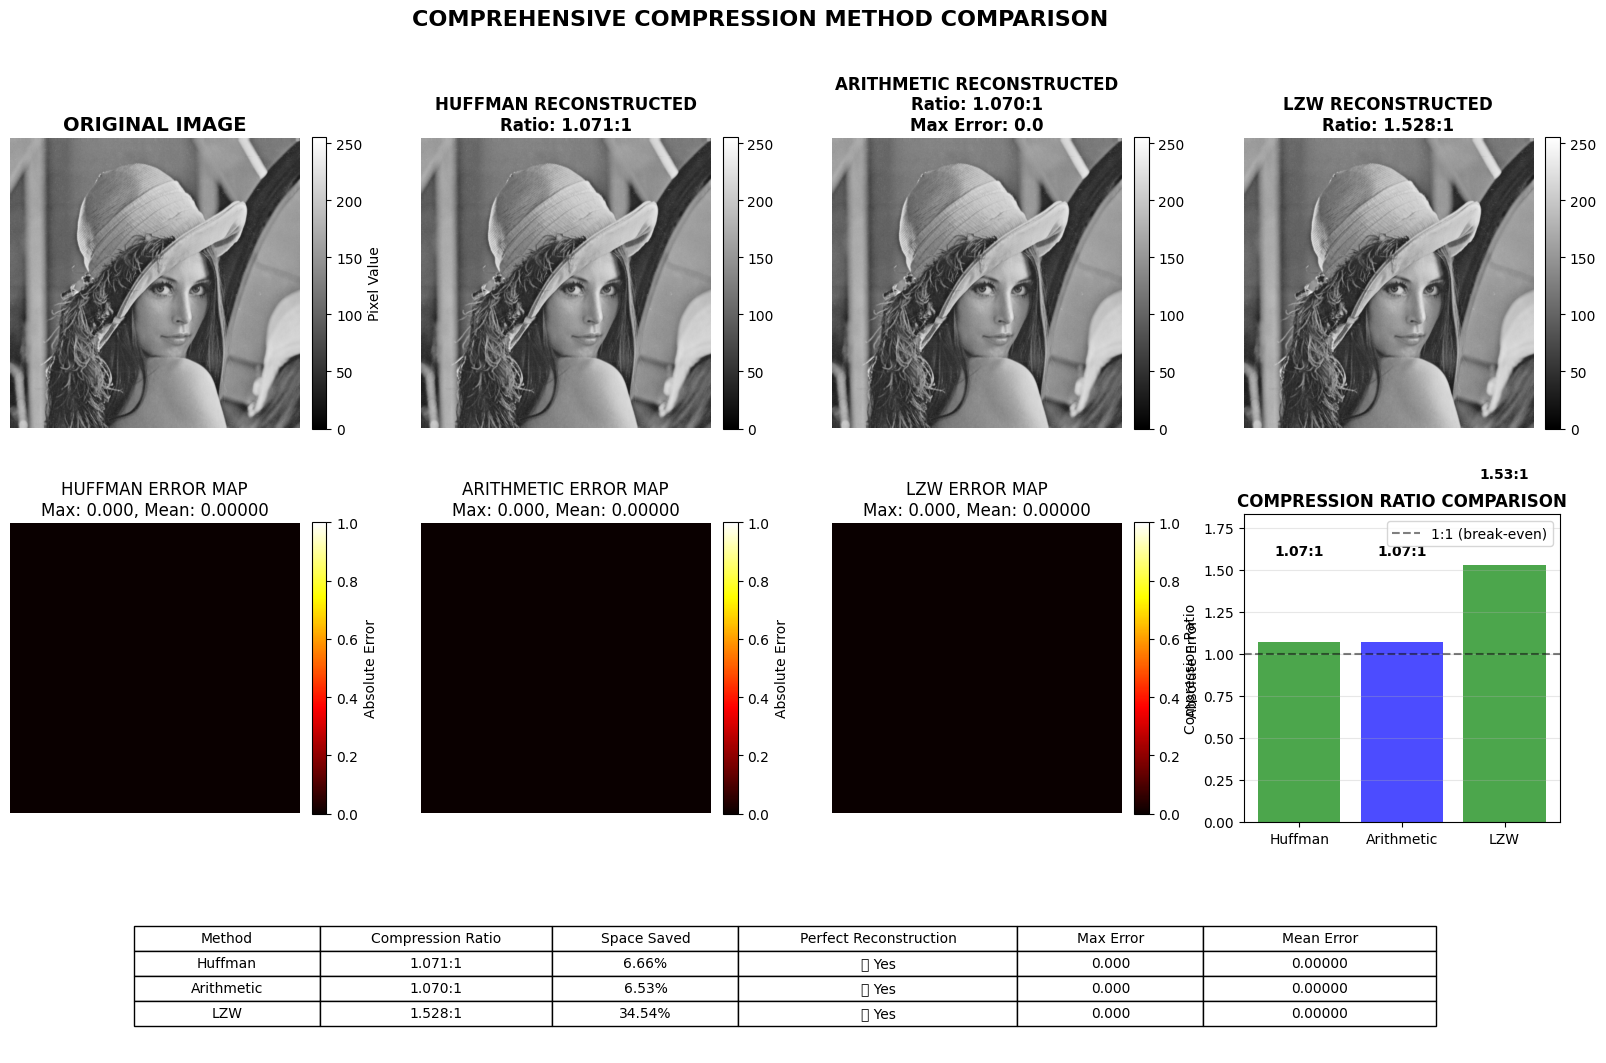


🔍 Generating zoomed comparison...


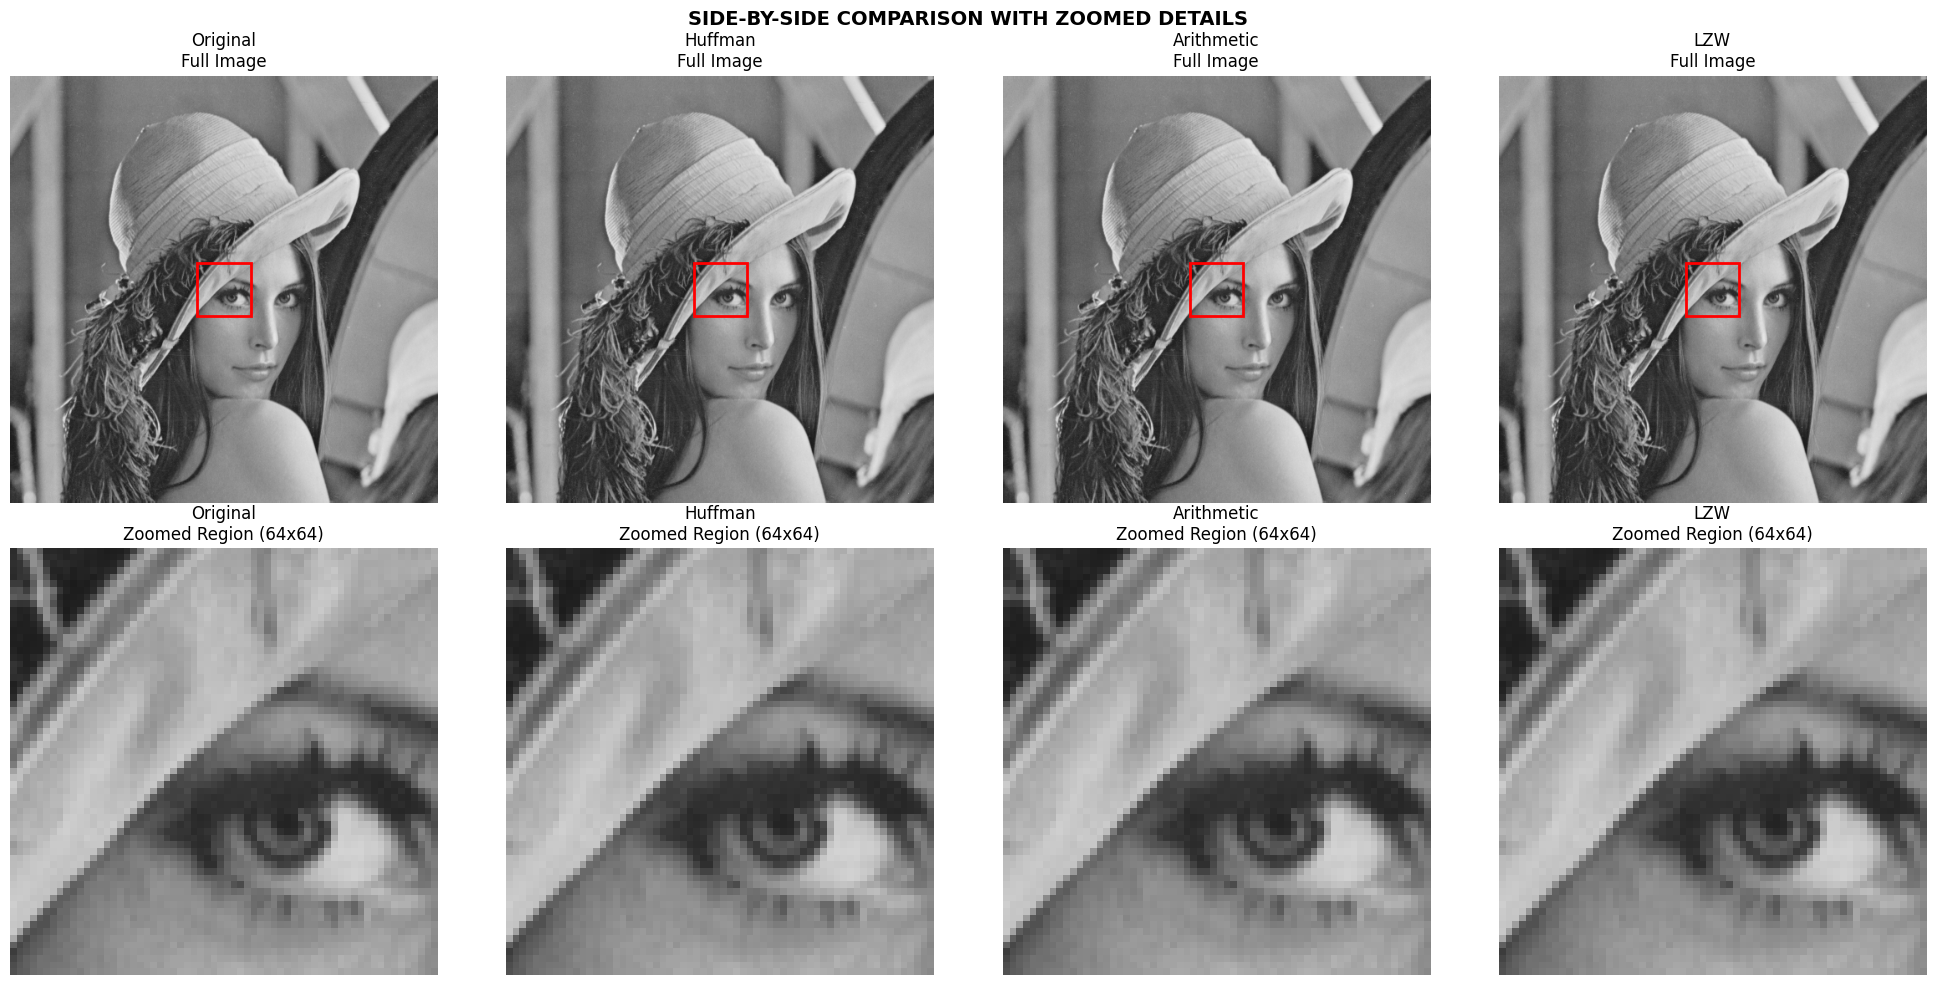


📈 Generating histogram comparison...


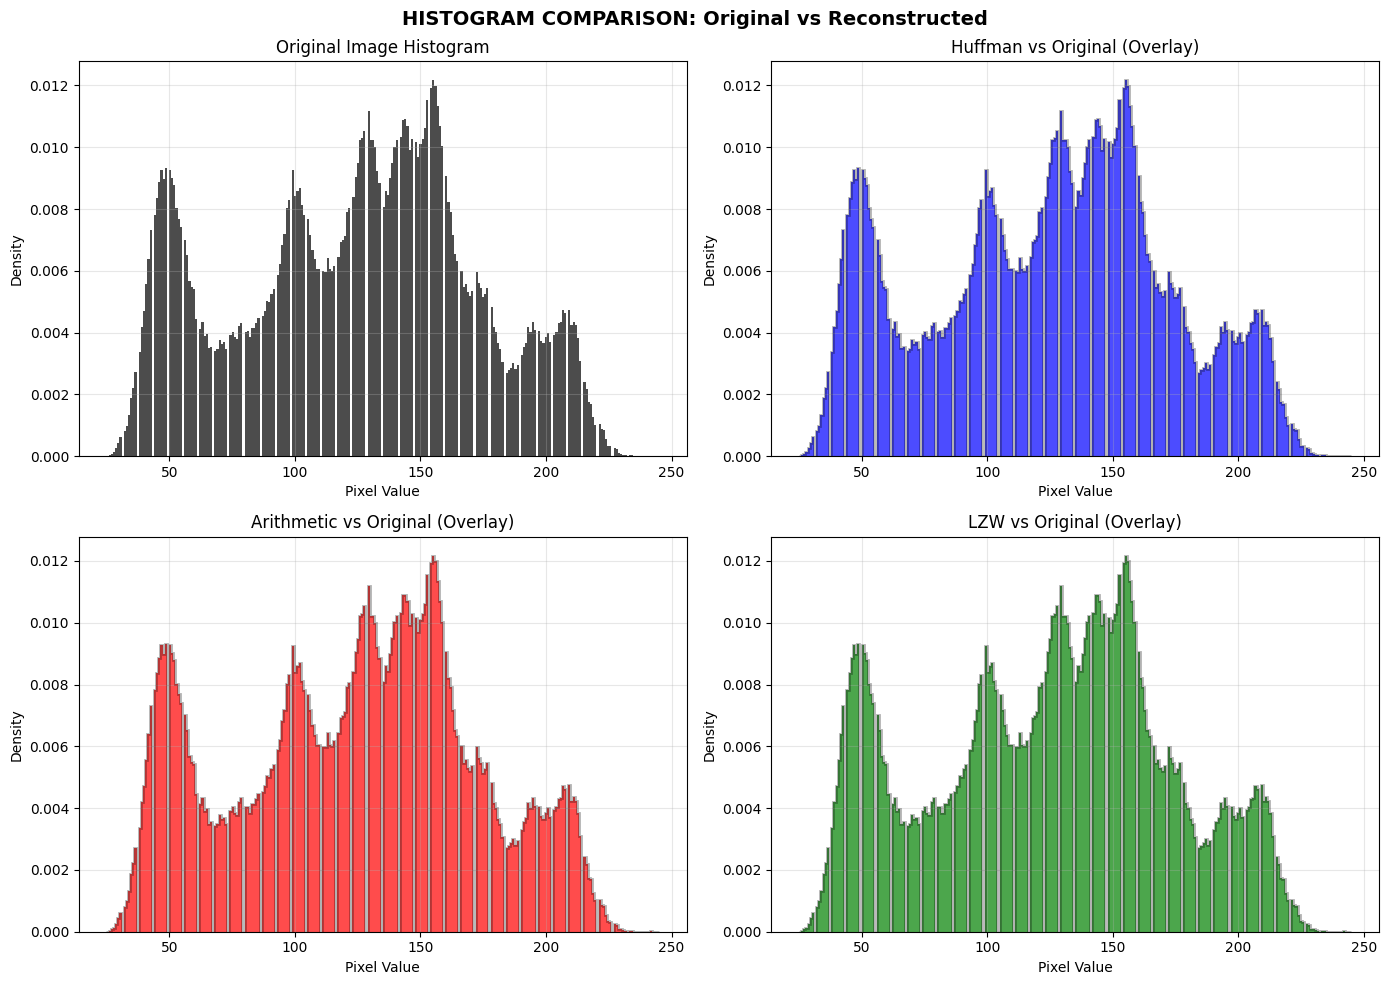


INDIVIDUAL METHOD ANALYSIS


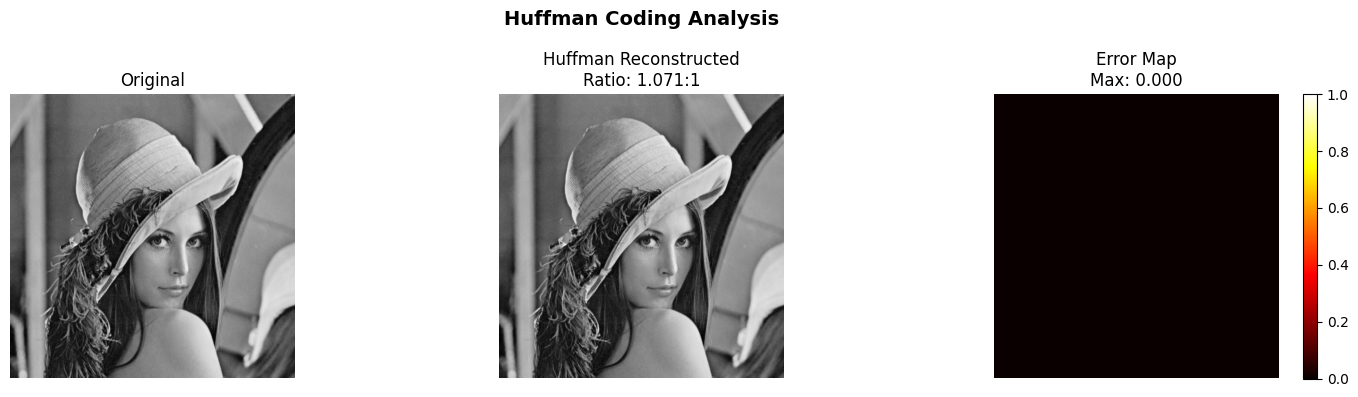

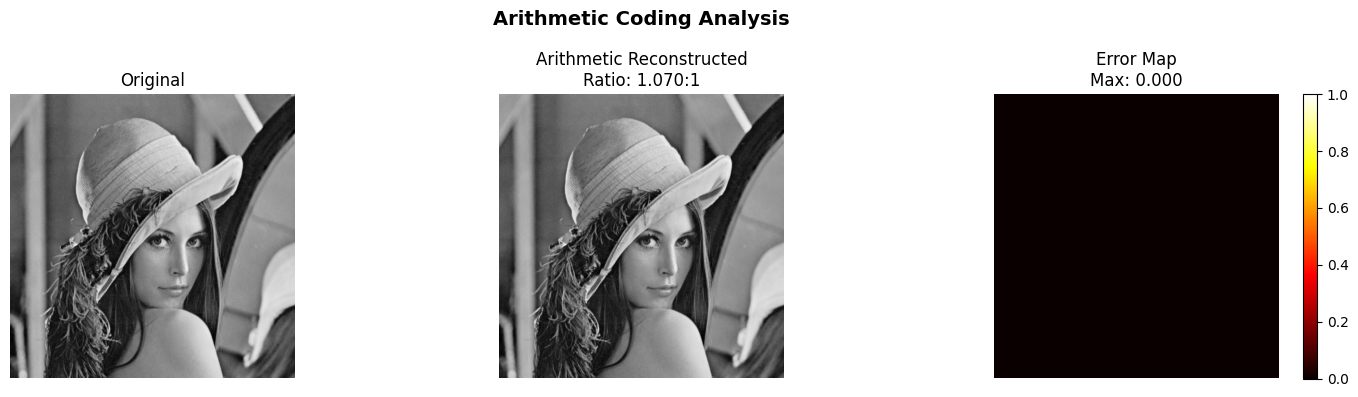

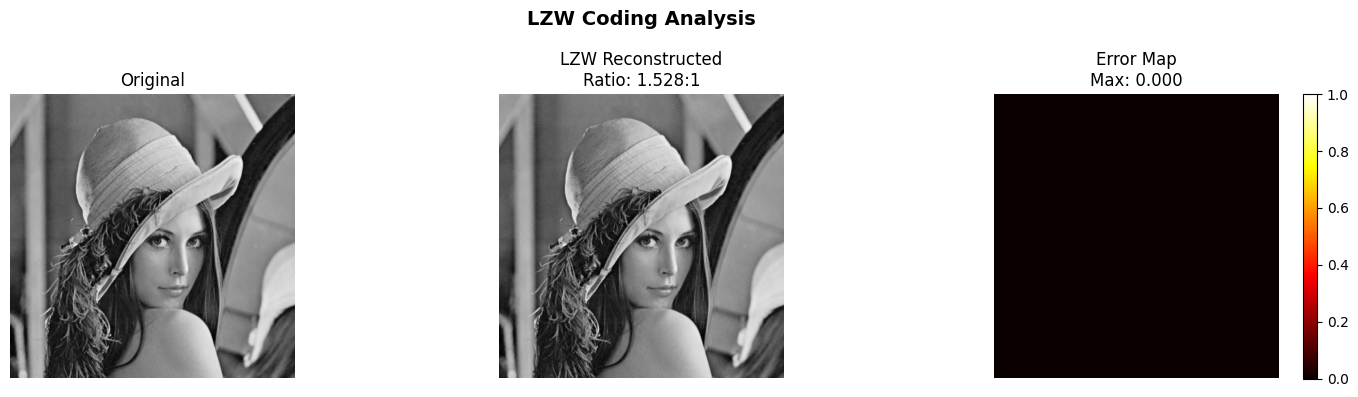

In [6]:
if __name__ == "__main__":
    # Load image
    image_path = "Lenna.png"
    print("Loading image...")
    image_array = load_and_preprocess_image(image_path)
    
    # Run compression
    results = demonstrate_compression(image_array)
    
    # 1. Comprehensive visualization (original + all reconstructions + error maps)
    print("\n📊 Generating comprehensive comparison...")
    visualize_all_methods_comprehensive(image_array, results)
    
    # 2. Side-by-side with zoom to see pixel-level details
    print("\n🔍 Generating zoomed comparison...")
    visualize_side_by_side_with_zoom(image_array, results)
    
    # 3. Histogram comparison
    print("\n📈 Generating histogram comparison...")
    visualize_histogram_comparison(image_array, results)
    
    # 4. Individual method analysis
    print("\n" + "="*60)
    print("INDIVIDUAL METHOD ANALYSIS")
    print("="*60)
    
    for method in ['Huffman', 'Arithmetic', 'LZW']:
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        
        # Original
        axes[0].imshow(image_array, cmap='gray')
        axes[0].set_title(f'Original')
        axes[0].axis('off')
        
        # Reconstructed
        axes[1].imshow(results[method]['decoded'], cmap='gray')
        axes[1].set_title(f'{method} Reconstructed\nRatio: {results[method]["ratio"]:.3f}:1')
        axes[1].axis('off')
        
        # Error map
        error = np.abs(image_array.astype(float) - results[method]['decoded'].astype(float))
        if method == 'Arithmetic' and error.max() > 10:
            im = axes[2].imshow(error, cmap='jet', vmin=0, vmax=255)
            axes[2].set_title(f'Error Map\nMax: {error.max():.1f}', color='red')
        else:
            im = axes[2].imshow(error, cmap='hot', vmin=0, vmax=1)
            axes[2].set_title(f'Error Map\nMax: {error.max():.3f}')
        
        plt.colorbar(im, ax=axes[2])
        axes[2].axis('off')
        
        plt.suptitle(f'{method} Coding Analysis', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()